فصل دوم: ماشین‌لرنینگ روی صدا

درس 5:


# 🧩  استخراج ویژگی‌های پیشرفته برای ماشین لرنینگ

### 1️⃣ نصب و وارد کردن کتابخانه‌ها

In [1]:
# %pip install librosa soundfile matplotlib sounddevice numpy pandas scipy --quiet
# OR
%pip install -v -i https://mirror-pypi.runflare.com/simple librosa soundfile matplotlib sounddevice numpy pandas scipy --trusted-host mirror-pypi.runflare.com

Using pip 26.1.1 from c:\Users\mosta\AppData\Local\Programs\Python\Python312\Lib\site-packages\pip (python 3.12)
Looking in indexes: https://mirror-pypi.runflare.com/simple
Note: you may need to restart the kernel to use updated packages.


In [2]:
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sounddevice as sd
import soundfile as sf

### 2️⃣ تست زنده: صدادار در برابر بی‌صدا


In [12]:
duration = 2 
sr = 44100

print(" 🎙️ تست اول: لطفا بگویید آآآآآآآآ")
rec_vowel = sd.rec(int(sr * duration), samplerate=sr, channels=1)
sd.wait()
sf.write("vowel_A.wav", rec_vowel, sr)
print("  ذخیره شد")

print(" 🎙️ تست دوم: لطفا بگویید شـشـشـشـش")
rec_noise = sd.rec(int(sr * duration), samplerate=sr, channels=1)
sd.wait()
sf.write("noise_Sh.wav", rec_noise, sr)
print("  ذخیره شد")


 🎙️ تست اول: لطفا بگویید آآآآآآآآ
  ذخیره شد
 🎙️ تست دوم: لطفا بگویید شـشـشـشـش
  ذخیره شد


### 3️⃣ ZCR استخراج  

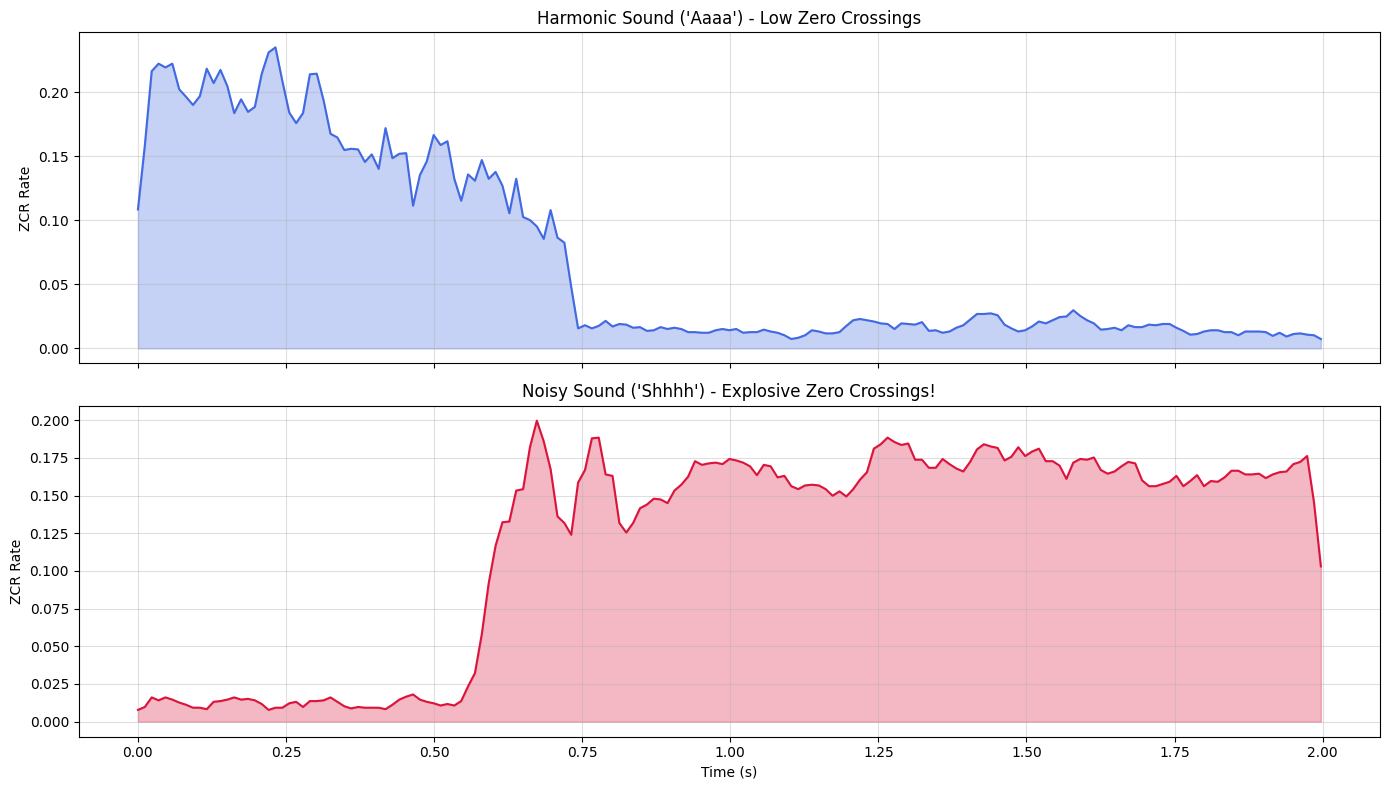

In [17]:
y_a, sr = librosa.load("vowel_A.wav", sr=None)
y_sh, _ = librosa.load("noise_Sh.wav", sr=None)

zcr_a = librosa.feature.zero_crossing_rate(y_a)[0]
zcr_sh = librosa.feature.zero_crossing_rate(y_sh)[0]

fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(14, 8), sharex=True)

times_a = librosa.times_like(zcr_a, sr=sr)
ax[0].plot(times_a, zcr_a, color='royalblue', label="ZCR ('Aaaaa')")
ax[0].set(title="Harmonic Sound ('Aaaa') - Low Zero Crossings", ylabel="ZCR Rate")
ax[0].fill_between(times_a, zcr_a, alpha=0.3, color='royalblue')
ax[0].grid(True, alpha=0.4)

times_sh = librosa.times_like(zcr_sh, sr=sr)
ax[1].plot(times_sh, zcr_sh, color='crimson', label="ZCR ('Shhhh')")
ax[1].set(title="Noisy Sound ('Shhhh') - Explosive Zero Crossings!", xlabel="Time (s)", ylabel="ZCR Rate")
ax[1].fill_between(times_sh, zcr_sh, alpha=0.3, color='crimson')
ax[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()


### 4️⃣ مرکز ثقل طیفی

 🎙️ :یک کلمه بگویید و در آخر آن سوت بزنید یا صدایتان را زیر کنید


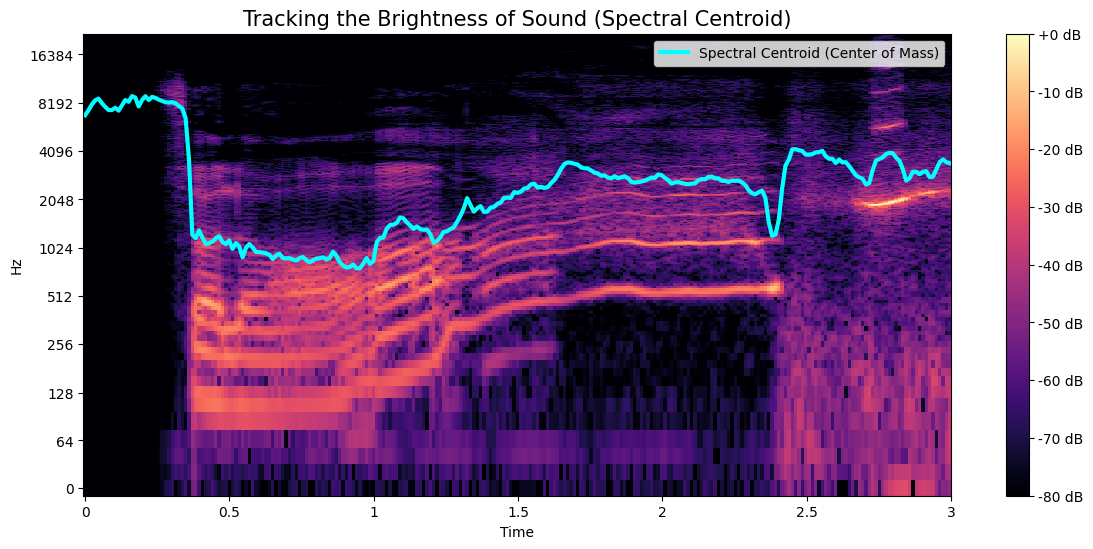

In [23]:

# ضبط یک جمله کوتاه با بالا و پایین بردن لحن صدا
print(" 🎙️ :یک کلمه بگویید و در آخر آن سوت بزنید یا صدایتان را زیر کنید")
rec_word = sd.rec(int(sr * 3), samplerate=sr, channels=1)
sd.wait()
sf.write("word_centroid.wav", rec_word, sr)

y_word, sr = librosa.load("word_centroid.wav", sr=None)

# محاسبه اسپکتروگرام و مرکز ثقل
S, phase = librosa.magphase(librosa.stft(y=y_word))
centroid = librosa.feature.spectral_centroid(S=S, sr=sr)[0]
times = librosa.times_like(centroid, sr=sr)

# رسم مرکز ثقل روی اسپکتروگرام
plt.figure(figsize=(14, 6))
librosa.display.specshow(librosa.amplitude_to_db(S, ref=np.max), y_axis='log', x_axis='time', sr=sr, cmap='magma')
plt.plot(times, centroid, color='cyan', linewidth=3, label='Spectral Centroid (Center of Mass)')

plt.colorbar(format='%+2.0f dB')
plt.title("Tracking the Brightness of Sound (Spectral Centroid)", fontsize=15)
plt.legend(loc='upper right')
plt.show()


### 5️⃣ مهندسی ویژگی‌ها: سوخت‌گیری برای هوش مصنوعی


In [24]:

# استخراج ویژگی‌ها برای صدای "آ" به عنوان نمونه
mfccs = librosa.feature.mfcc(y=y_a, sr=sr, n_mfcc=13)
zcr = librosa.feature.zero_crossing_rate(y=y_a)
centroid = librosa.feature.spectral_centroid(y=y_a, sr=sr)

mfccs_mean = np.mean(mfccs, axis=1)  
zcr_mean = np.mean(zcr)              
centroid_mean = np.mean(centroid)    

print("ویژگی‌ها با موفقیت استخراج و فشرده شدند")

ویژگی‌ها با موفقیت استخراج و فشرده شدند


### 6️⃣ تولد اولین دیتاست با پانداس


In [25]:
features_dict = {}

for i in range(13):
    features_dict[f'MFCC_{i+1}'] = mfccs_mean[i]

features_dict['ZCR'] = zcr_mean
features_dict['Spectral_Centroid'] = centroid_mean

features_dict['Emotion'] = 'Neutral' # در پروژه‌ی بعدی اینها را پویا می‌کنیم

df = pd.DataFrame([features_dict])

print("\n :Machine Learning دیتافریم آماده برای")
display(df)



 :Machine Learning دیتافریم آماده برای


,MFCC_1,MFCC_2,MFCC_3,MFCC_4,MFCC_5,MFCC_6,MFCC_7,MFCC_8,MFCC_9,MFCC_10,MFCC_11,MFCC_12,MFCC_13,ZCR,Spectral_Centroid,Emotion
0,-739.032959,127.594566,22.871786,19.185646,15.834525,8.236817,1.768375,5.325808,11.789434,6.794985,2.74138,1.80804,-2.729388,0.069762,4141.491329,Neutral


### 🏁 جمع‌بندی


ما امروز فراتر از حنجره رفتیم و بافتِ صدا را آنالیز کردیم

توانستیم نویز و حروف بی‌صدا را از روی نوسانات سریعشان تشخیص دهیم

مفهوم "روشنی" و "تیرگی" صدا را فرموله کردیم

و مهم‌تر از همه، دیتافریم پانداس را ساختیم؛ جدولی که زبانِ مشترک بین "سیگنال‌های صوتی" و "مدل‌های هوش مصنوعی" است


**آماده‌اید؟**

در جلسه آینده، قرار است این تکنیک‌ها را روی ۱۰۰ فایل صوتی از دیتاست احساسات اجرا کنیم و دیتابیس اختصاصی خودمان را برای آموزش مدل تشخیص احساس بسازیم